In [291]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/madhuraatmarambhagat/milk-production-dataset/Mik_Pro.csv


# 1 - Load the data and Explore it

In [292]:
df = pd.read_csv("/kaggle/input/datasets/madhuraatmarambhagat/milk-production-dataset/Mik_Pro.csv")
df.head()

,Year,Milk Production
0,1980,1620
1,1981,1899
2,1982,2015
3,1983,2096
4,1984,2110


In [293]:
df.describe()

,Year,Milk Production
count,43.000000,43.000000
mean,2001.000000,6513.837209
std,12.556539,3554.177749
min,1980.000000,1620.000000
25%,1990.500000,3845.500000
50%,2001.000000,6094.000000
75%,2011.500000,8466.500000
max,2022.000000,15041.000000


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             43 non-null     int64
 1   Milk Production  43 non-null     int64
dtypes: int64(2)
memory usage: 820.0 bytes


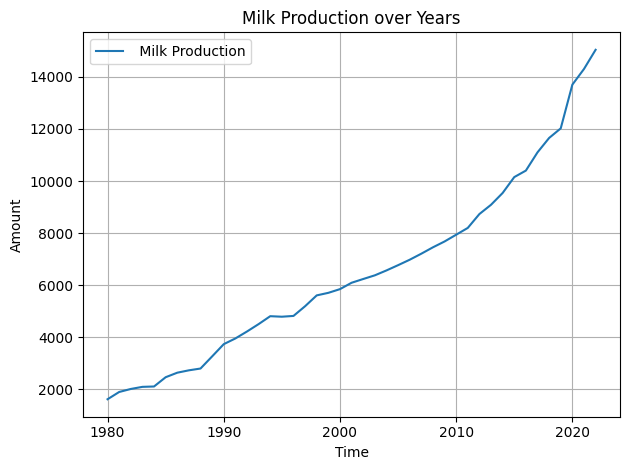

In [295]:
# Visualize the data
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df["Year"],df["Milk Production"],label =" Milk Production")
plt.legend()
plt.title("Milk Production over Years")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.tight_layout()
plt.grid("on")
plt.show()


### * Milk Production has been increasing since 1980.

In [296]:
df["Year"] = pd.to_datetime(df["Year"],format='%Y')
df.set_index("Year",inplace = True)
df.head()

,Milk Production
Year,
1980-01-01,1620
1981-01-01,1899
1982-01-01,2015
1983-01-01,2096
1984-01-01,2110


# 2 - Preprocessing and Modeling

In [297]:
from sklearn.preprocessing import MinMaxScaler
values = df.values.reshape(-1,1)
values

array([[ 1620],
       [ 1899],
       [ 2015],
       [ 2096],
       [ 2110],
       [ 2466],
       [ 2640],
       [ 2731],
       [ 2800],
       [ 3266],
       [ 3736],
       [ 3955],
       [ 4222],
       [ 4506],
       [ 4810],
       [ 4790],
       [ 4820],
       [ 5193],
       [ 5609],
       [ 5707],
       [ 5849],
       [ 6094],
       [ 6238],
       [ 6379],
       [ 6567],
       [ 6769],
       [ 6978],
       [ 7210],
       [ 7455],
       [ 7679],
       [ 7939],
       [ 8200],
       [ 8733],
       [ 9089],
       [ 9542],
       [10152],
       [10402],
       [11102],
       [11655],
       [12024],
       [13703],
       [14304],
       [15041]])

In [298]:
df.isnull().sum()

Milk Production    0
dtype: int64

In [299]:
scaler = MinMaxScaler()
scaled_val = scaler.fit_transform(values)
scaled_val

array([[0.        ],
       [0.02078832],
       [0.02943149],
       [0.03546681],
       [0.03650995],
       [0.06303554],
       [0.0760003 ],
       [0.08278072],
       [0.08792191],
       [0.12264362],
       [0.15766336],
       [0.17398107],
       [0.19387527],
       [0.21503614],
       [0.23768721],
       [0.236197  ],
       [0.23843231],
       [0.26622457],
       [0.29722077],
       [0.30452276],
       [0.3151032 ],
       [0.33335817],
       [0.34408762],
       [0.35459355],
       [0.36860145],
       [0.38365248],
       [0.3992251 ],
       [0.41651144],
       [0.43476641],
       [0.45145667],
       [0.4708293 ],
       [0.49027643],
       [0.52999031],
       [0.55651591],
       [0.59026898],
       [0.63572014],
       [0.65434766],
       [0.70650473],
       [0.74770881],
       [0.77520304],
       [0.90030549],
       [0.94508606],
       [1.        ]])

In [300]:
seq_len = 3
def create_sliding_window(data,seq_len):
    X_seq,y_seq = [],[]
    for i in range(len(data) - seq_len):
        X_seq.append(data[i:i + seq_len])
        y_seq.append(data[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

X,y = create_sliding_window(scaled_val,seq_len)
X.shape,y.shape

((40, 3, 1), (40, 1))

In [301]:
X

array([[[0.        ],
        [0.02078832],
        [0.02943149]],

       [[0.02078832],
        [0.02943149],
        [0.03546681]],

       [[0.02943149],
        [0.03546681],
        [0.03650995]],

       [[0.03546681],
        [0.03650995],
        [0.06303554]],

       [[0.03650995],
        [0.06303554],
        [0.0760003 ]],

       [[0.06303554],
        [0.0760003 ],
        [0.08278072]],

       [[0.0760003 ],
        [0.08278072],
        [0.08792191]],

       [[0.08278072],
        [0.08792191],
        [0.12264362]],

       [[0.08792191],
        [0.12264362],
        [0.15766336]],

       [[0.12264362],
        [0.15766336],
        [0.17398107]],

       [[0.15766336],
        [0.17398107],
        [0.19387527]],

       [[0.17398107],
        [0.19387527],
        [0.21503614]],

       [[0.19387527],
        [0.21503614],
        [0.23768721]],

       [[0.21503614],
        [0.23768721],
        [0.236197  ]],

       [[0.23768721],
        [0.236197  ],
    

In [302]:
y

array([[0.03546681],
       [0.03650995],
       [0.06303554],
       [0.0760003 ],
       [0.08278072],
       [0.08792191],
       [0.12264362],
       [0.15766336],
       [0.17398107],
       [0.19387527],
       [0.21503614],
       [0.23768721],
       [0.236197  ],
       [0.23843231],
       [0.26622457],
       [0.29722077],
       [0.30452276],
       [0.3151032 ],
       [0.33335817],
       [0.34408762],
       [0.35459355],
       [0.36860145],
       [0.38365248],
       [0.3992251 ],
       [0.41651144],
       [0.43476641],
       [0.45145667],
       [0.4708293 ],
       [0.49027643],
       [0.52999031],
       [0.55651591],
       [0.59026898],
       [0.63572014],
       [0.65434766],
       [0.70650473],
       [0.74770881],
       [0.77520304],
       [0.90030549],
       [0.94508606],
       [1.        ]])

In [303]:
split = int(len(X) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((32, 3, 1), (8, 3, 1), (32, 1), (8, 1))

In [304]:
# LSTM Model
import tensorflow as tf
from sklearn.metrics import mean_squared_error

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64,activation = "tanh",kernel_regularizer=tf.keras.regularizers.l2(0.01),input_shape = (X_train.shape[1],X_train.shape[2])),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

early_stop = tf.keras.callbacks.EarlyStopping (
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)
model.compile(loss = tf.keras.losses.MeanSquaredError(),
             optimizer = tf.keras.optimizers.Adam(),
             metrics = ["mse"])

history = model.fit(X_train,y_train,epochs = 50,validation_data = (X_test,y_test),callbacks = [early_stop])

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1292 - mse: 0.1074 - val_loss: 0.6248 - val_mse: 0.6033
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.1177 - mse: 0.0961 - val_loss: 0.5978 - val_mse: 0.5765
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1146 - mse: 0.0934 - val_loss: 0.5712 - val_mse: 0.5503
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.1074 - mse: 0.0865 - val_loss: 0.5452 - val_mse: 0.5246
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1038 - mse: 0.0832 - val_loss: 0.5198 - val_mse: 0.4995
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0949 - mse: 0.0746 - val_loss: 0.4948 - val_mse: 0.4748
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0896 - mse: 0.0696 - val_loss: 0.4704 - val_mse: 0.4507
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0806 - mse: 0.0609 - val_loss: 0.4465 - val_mse: 0.4271
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0750 - mse: 0.0555 - val_los

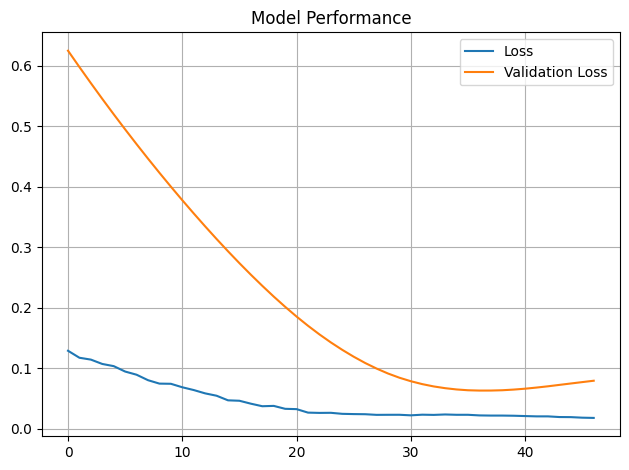

In [305]:
plt.figure()
plt.plot(history.history["loss"],label = "Loss")
plt.plot(history.history["val_loss"],label = "Validation Loss")
plt.legend()
plt.title("Model Performance")
plt.tight_layout()
plt.grid(True)
plt.show()

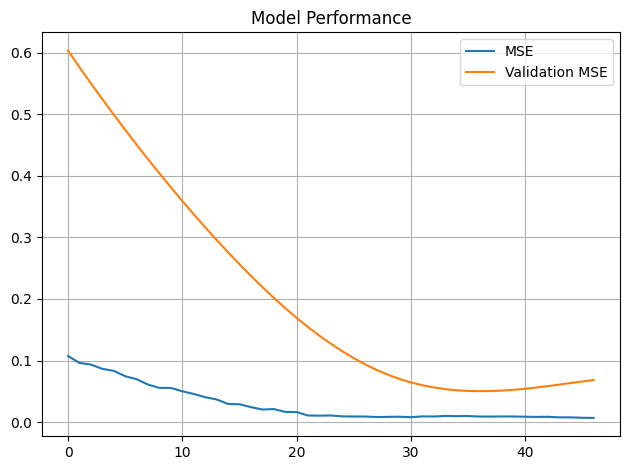

In [306]:
plt.figure()
plt.plot(history.history["mse"],label = "MSE")
plt.plot(history.history["val_mse"],label = "Validation MSE")
plt.legend()
plt.title("Model Performance")
plt.tight_layout()
plt.grid(True)
plt.show()

<Axes: >

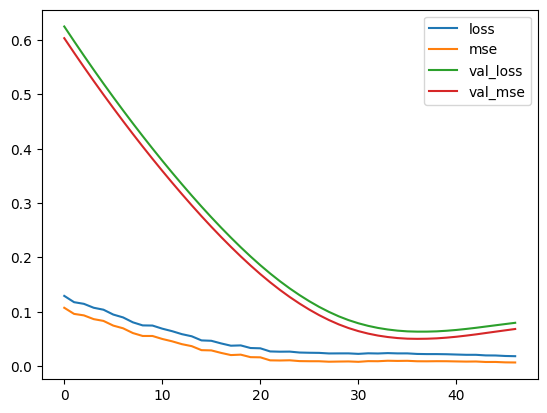

In [307]:
pd.DataFrame(history.history).plot()

# 3 - Predictions

In [308]:
y_test_true = scaler.inverse_transform(y_test)
y_test_true

array([[10152.],
       [10402.],
       [11102.],
       [11655.],
       [12024.],
       [13703.],
       [14304.],
       [15041.]])

In [309]:
y_pred = model.predict(X_test)
y_pred_true = scaler.inverse_transform(y_pred)
y_pred_true

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


array([[ 8463.408 ],
       [ 8711.008 ],
       [ 8969.897 ],
       [ 9250.609 ],
       [ 9514.2295],
       [ 9837.003 ],
       [10242.329 ],
       [10731.475 ]], dtype=float32)

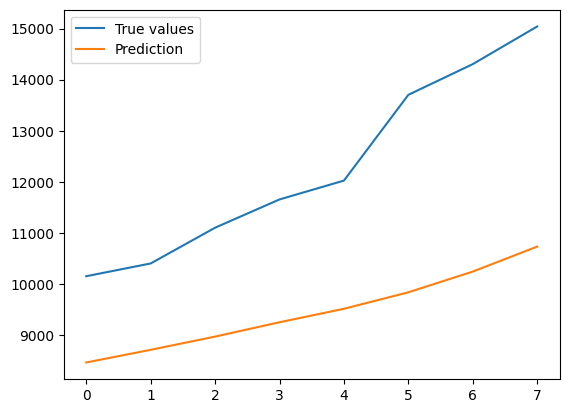

In [310]:
plt.figure()
plt.plot(y_test_true,label = "True values")
plt.plot(y_pred_true,label = "Prediction")
plt.legend()
plt.show()

# 4 - Evaluation

In [311]:
mse = mean_squared_error(y_test_true,y_pred_true)
print(mse)

9043976.659816267


In [312]:
rmse = np.sqrt(mse)
print(rmse)

3007.3205116542313


# 5 - Alternative Model

In [315]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.GRU(units = 64,activation = "tanh"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model_gru.compile(loss = "MeanSquaredError",
                 optimizer = "adam",
                 metrics = ["mse"])

early_stop = tf.keras.callbacks.EarlyStopping(monitor = "val_loss",
                                             patience = 10,
                                            restore_best_weights = True)
history_gru = model_gru.fit(X_train,y_train,epochs = 50,validation_data = (X_test,y_test),callbacks = [early_stop])

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0653 - mse: 0.0653WARNING:tensorflow:5 out of the last 97 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x787ec270d8a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0653 - mse: 0.0653 - val_loss: 0.3350 - val_mse: 0.3350
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0541 - mse: 0.0541 - val_loss: 0.2920 - val_mse: 0.292

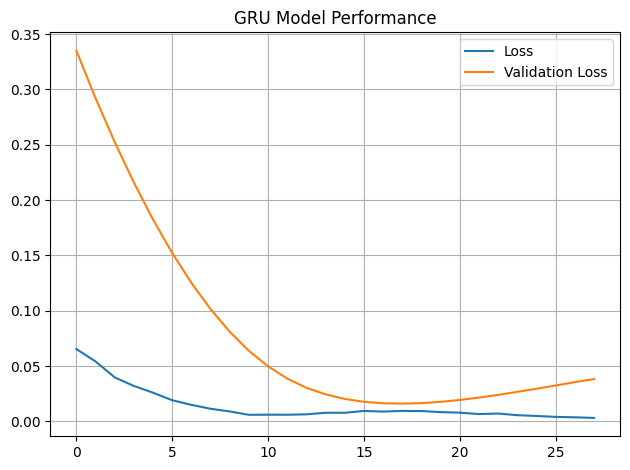

In [316]:
plt.figure()
plt.plot(history_gru.history["loss"],label = "Loss")
plt.plot(history_gru.history["val_loss"],label = "Validation Loss")
plt.legend()
plt.title("GRU Model Performance")
plt.tight_layout()
plt.grid(True)
plt.show()

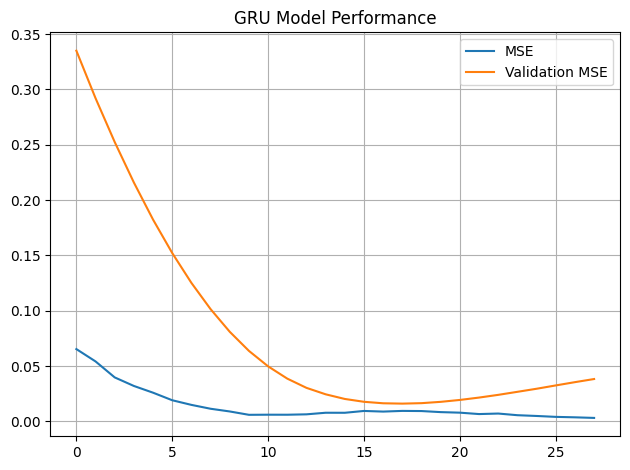

In [317]:
plt.figure()
plt.plot(history_gru.history["mse"],label = "MSE")
plt.plot(history_gru.history["val_mse"],label = "Validation MSE")
plt.legend()
plt.title("GRU Model Performance")
plt.tight_layout()
plt.grid(True)
plt.show()

# 6 - Comparison of LSTM VS GRU

In [320]:
y_gru_predict = model_gru.predict(X_test)
y_gru_predict_true = scaler.inverse_transform(y_gru_predict)
y_gru_predict_true

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


array([[ 9421.262],
       [ 9771.377],
       [10085.422],
       [10461.02 ],
       [10837.971],
       [11220.818],
       [11879.184],
       [12542.977]], dtype=float32)

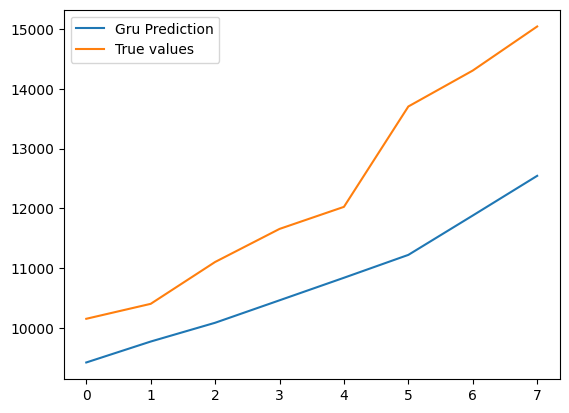

In [321]:
plt.figure()
plt.plot(y_gru_predict_true,label = "Gru Prediction")
plt.plot(y_test_true,label = "True values")
plt.legend()
plt.show()

In [322]:
mse = mean_squared_error(y_test_true,y_gru_predict_true)
mse

2884803.8994174013

In [323]:
rmse_gru = np.sqrt(mse)
rmse_gru

np.float64(1698.471047565251)